In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print(f"Data loaded! Training samples: {len(train_dataset)}")

100%|██████████| 562M/562M [00:02<00:00, 244MB/s]


Data loaded! Training samples: 112800


In [57]:
class ANN_Autoencoder_v1(nn.Module):
    def __init__(self, bottleneck_size=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent
ann_model_1 = ANN_Autoencoder_v1(bottleneck_size=64).to(device)

In [25]:
def train_my_model(model, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    loss_history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            output, _ = model(images)
            loss = criterion(output, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
    return loss_history

In [58]:
num_epochs = 20
learning_rate = 1e-3
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ann_model_1.parameters(), lr=learning_rate)
ann_loss_1 = []
print(f"Training ANN Design 1 (B-64) for {num_epochs} epochs...")

for epoch in range(num_epochs):
    ann_model_1.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        reconstructed, _ = ann_model_1(images)
        loss = criterion(reconstructed, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    ann_loss_1.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

print("Training Complete!")

Training Fair ANN Design 1 (B-64) for 20 epochs...
Epoch [5/20], Loss: 0.006525
Epoch [10/20], Loss: 0.004786
Epoch [15/20], Loss: 0.004452
Epoch [20/20], Loss: 0.004364
Training Complete! ANN Design 1 is now ready for comparison.


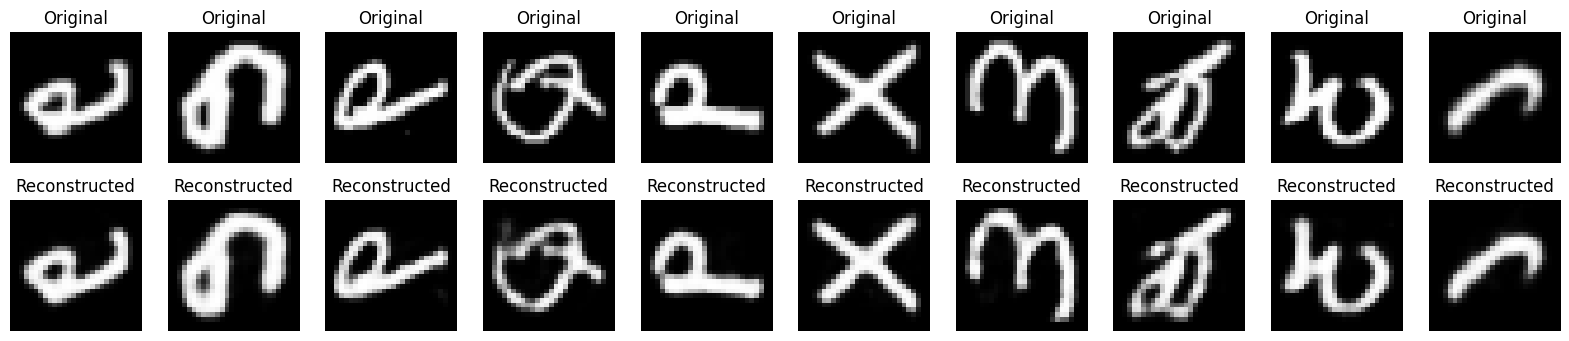

In [27]:
import matplotlib.pyplot as plt
def visualize_reconstruction(model, dataloader):
    model.eval()
    model.to(device)
    images, _ = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()
    plt.figure(figsize=(20, 4))
    for i in range(10):

        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')

    plt.show()
visualize_reconstruction(ann_model_1, test_loader)

In [30]:
class ANN_Autoencoder_v2(nn.Module):
    def __init__(self, bottleneck_size=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 128),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

print("Training ANN Design 2 (Bottleneck 32)...")
ann_model_2 = ANN_Autoencoder_v2(bottleneck_size=32)
ann_loss_2 = train_my_model(ann_model_2, epochs=30)

Training ANN Design 2 (Bottleneck 32)...
Epoch [1/30], Loss: 0.0282
Epoch [2/30], Loss: 0.0121
Epoch [3/30], Loss: 0.0095
Epoch [4/30], Loss: 0.0084
Epoch [5/30], Loss: 0.0076
Epoch [6/30], Loss: 0.0071
Epoch [7/30], Loss: 0.0067
Epoch [8/30], Loss: 0.0064
Epoch [9/30], Loss: 0.0062
Epoch [10/30], Loss: 0.0061
Epoch [11/30], Loss: 0.0060
Epoch [12/30], Loss: 0.0059
Epoch [13/30], Loss: 0.0058
Epoch [14/30], Loss: 0.0057
Epoch [15/30], Loss: 0.0057
Epoch [16/30], Loss: 0.0056
Epoch [17/30], Loss: 0.0056
Epoch [18/30], Loss: 0.0056
Epoch [19/30], Loss: 0.0055
Epoch [20/30], Loss: 0.0055
Epoch [21/30], Loss: 0.0055
Epoch [22/30], Loss: 0.0054
Epoch [23/30], Loss: 0.0054
Epoch [24/30], Loss: 0.0054
Epoch [25/30], Loss: 0.0054
Epoch [26/30], Loss: 0.0053
Epoch [27/30], Loss: 0.0053
Epoch [28/30], Loss: 0.0053
Epoch [29/30], Loss: 0.0053
Epoch [30/30], Loss: 0.0053


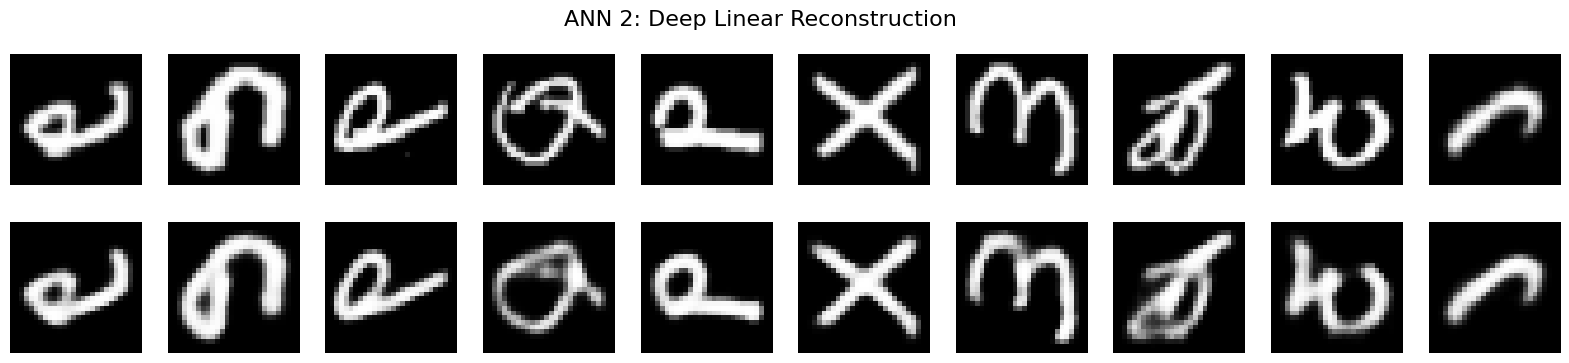

In [31]:
import torch
import matplotlib.pyplot as plt
def visualize_results(model, dataloader, device, title="Model Results"):
    model.eval()
    model.to(device)
    images, _ = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    plt.figure(figsize=(20, 4))
    plt.suptitle(title, fontsize=16)

    for i in range(10):
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("Original", size='large')
        plt.axis('off')
        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("Reconstructed", size='large')
        plt.axis('off')

    plt.show()
visualize_results(ann_model_2, test_loader, device, title="ANN 2: Deep Linear Reconstruction")


In [56]:
class CNN_Super(nn.Module):
    def __init__(self, bottleneck_size=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, bottleneck_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 128 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent
epochs = 20
print("Training CNN Super (B-64)...")
cnn_model_1 = CNN_Super(bottleneck_size=64).to(device)
cnn_loss_1 = train_my_model(cnn_model_1, epochs=epochs)

Training CNN Super (B-64)...
Epoch [1/20], Loss: 0.0129
Epoch [2/20], Loss: 0.0029
Epoch [3/20], Loss: 0.0023
Epoch [4/20], Loss: 0.0021
Epoch [5/20], Loss: 0.0019
Epoch [6/20], Loss: 0.0018
Epoch [7/20], Loss: 0.0018
Epoch [8/20], Loss: 0.0017
Epoch [9/20], Loss: 0.0017
Epoch [10/20], Loss: 0.0016
Epoch [11/20], Loss: 0.0016
Epoch [12/20], Loss: 0.0015
Epoch [13/20], Loss: 0.0015
Epoch [14/20], Loss: 0.0015
Epoch [15/20], Loss: 0.0015
Epoch [16/20], Loss: 0.0015
Epoch [17/20], Loss: 0.0014
Epoch [18/20], Loss: 0.0014
Epoch [19/20], Loss: 0.0014
Epoch [20/20], Loss: 0.0014


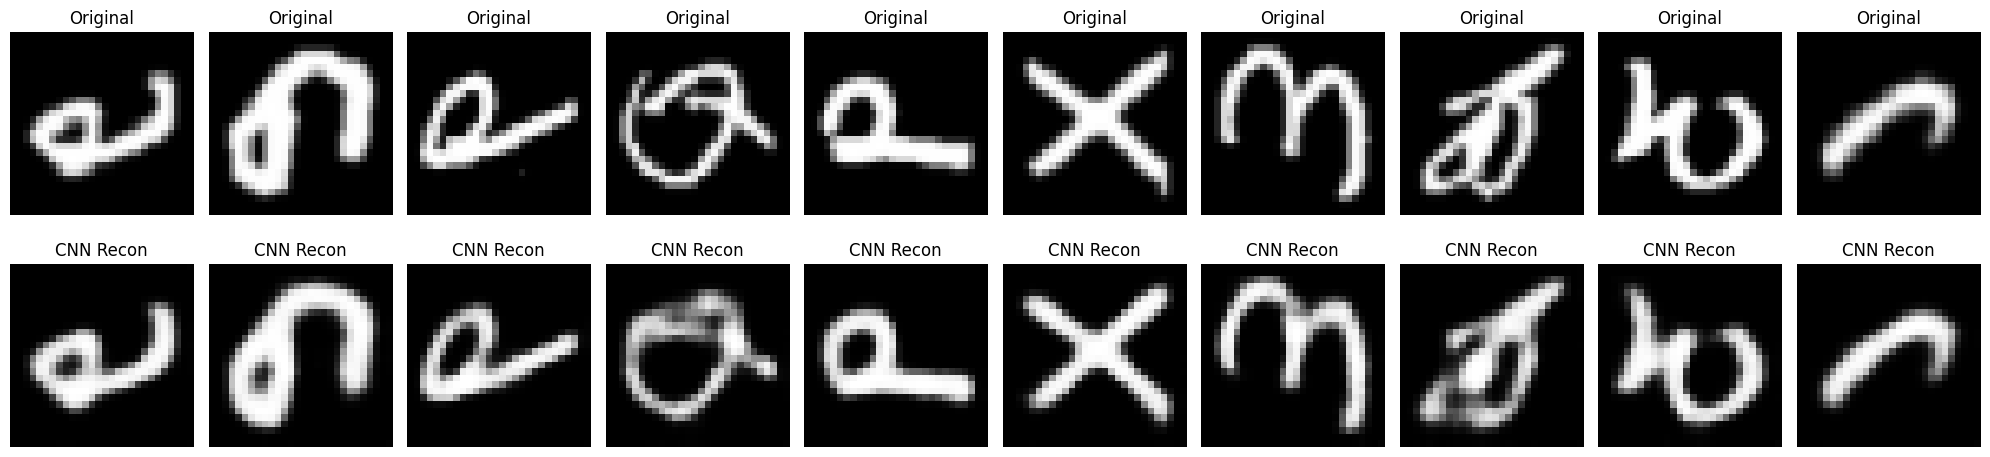

In [33]:
import torch
import matplotlib.pyplot as plt

def visualize_cnn_reconstruction(model, dataloader, device):
    model.eval()
    model.to(device)
    images, _ = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    plt.figure(figsize=(20, 5))

    for i in range(10):

        ax = plt.subplot(2, 10, i + 1)
        img_original = images[i].squeeze()
        plt.imshow(img_original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        ax = plt.subplot(2, 10, i + 11)
        img_recon = reconstructed[i].squeeze()
        plt.imshow(img_recon, cmap='gray')
        plt.title("CNN Recon")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
visualize_cnn_reconstruction(cnn_model_1, test_loader, device)

In [45]:
class CNN_Autoencoder_V2(nn.Module):
    def __init__(self, bottleneck_size=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, bottleneck_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent
cnn_model_2 = CNN_Autoencoder_V2(bottleneck_size=32).to(device)
optimizer = torch.optim.Adam(cnn_model_2.parameters(), lr=1e-3)
criterion = nn.MSELoss()
cnn_loss_2 = []
for epoch in range(30):
    cnn_model_2.train()
    total = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        out, _ = cnn_model_2(imgs)
        loss = criterion(out, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    avg = total/len(train_loader)
    cnn_loss_2.append(avg)
    print(f"Epoch {epoch+1}/30 | Loss: {avg:.6f}")

Epoch 1/30 | Loss: 0.014445
Epoch 2/30 | Loss: 0.007167
Epoch 3/30 | Loss: 0.006498
Epoch 4/30 | Loss: 0.006125
Epoch 5/30 | Loss: 0.005859
Epoch 6/30 | Loss: 0.005662
Epoch 7/30 | Loss: 0.005502
Epoch 8/30 | Loss: 0.005390
Epoch 9/30 | Loss: 0.005299
Epoch 10/30 | Loss: 0.005224
Epoch 11/30 | Loss: 0.005160
Epoch 12/30 | Loss: 0.005103
Epoch 13/30 | Loss: 0.005057
Epoch 14/30 | Loss: 0.005017
Epoch 15/30 | Loss: 0.004976
Epoch 16/30 | Loss: 0.004945
Epoch 17/30 | Loss: 0.004913
Epoch 18/30 | Loss: 0.004889
Epoch 19/30 | Loss: 0.004860
Epoch 20/30 | Loss: 0.004843
Epoch 21/30 | Loss: 0.004818
Epoch 22/30 | Loss: 0.004801
Epoch 23/30 | Loss: 0.004783
Epoch 24/30 | Loss: 0.004767
Epoch 25/30 | Loss: 0.004749
Epoch 26/30 | Loss: 0.004737
Epoch 27/30 | Loss: 0.004721
Epoch 28/30 | Loss: 0.004712
Epoch 29/30 | Loss: 0.004700
Epoch 30/30 | Loss: 0.004686


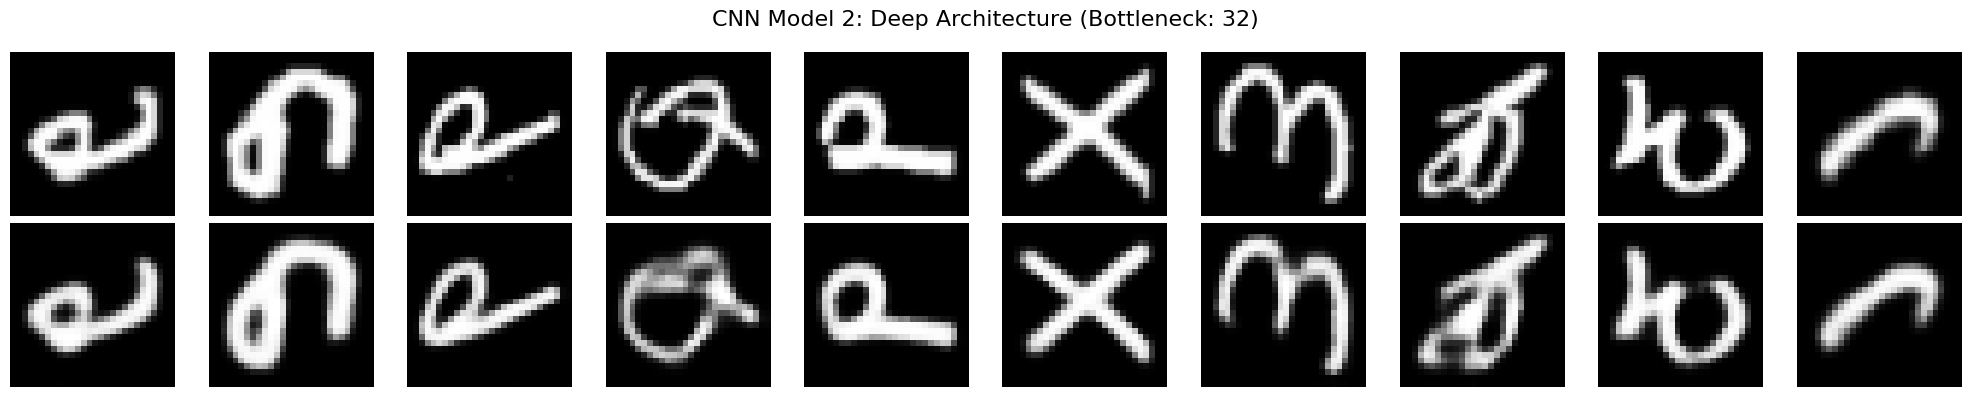

In [46]:
import torch
import matplotlib.pyplot as plt

def visualize_cnn2_results(model, dataloader, device):
    model.eval()
    model.to(device)
    images, _ = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _ = model(images)
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    plt.figure(figsize=(20, 4))
    plt.suptitle("CNN Model 2: Deep Architecture (Bottleneck: 32)", fontsize=16)

    for i in range(10):
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("Input", size='large')
        plt.axis('off')
        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("CNN2 Output", size='large')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_cnn2_results(cnn_model_2, test_loader, device)

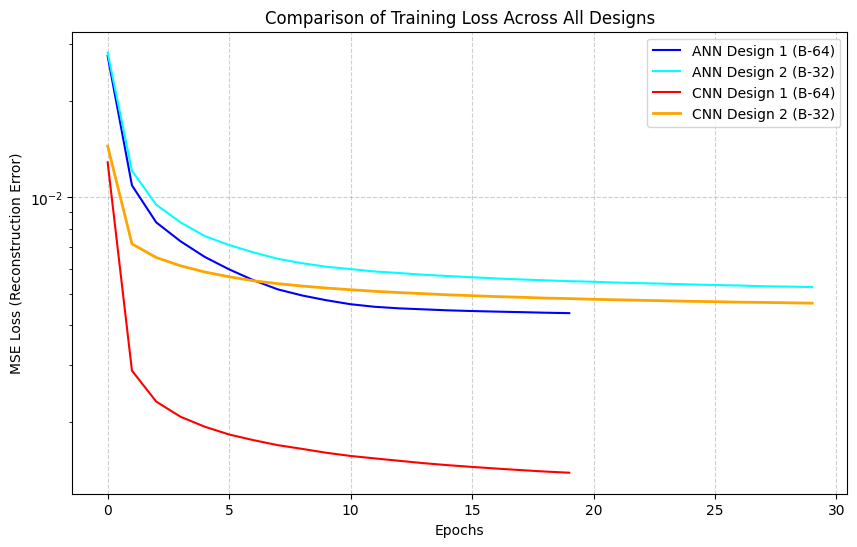

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(ann_loss_1, label='ANN Design 1 (B-64)', color='blue')
plt.plot(ann_loss_2, label='ANN Design 2 (B-32)', color='cyan')

plt.plot(cnn_loss_1, label='CNN Design 1 (B-64)', color='red')
plt.plot(cnn_loss_2, label='CNN Design 2 (B-32)', color='orange', linewidth=2)

plt.title('Comparison of Training Loss Across All Designs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Reconstruction Error)')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

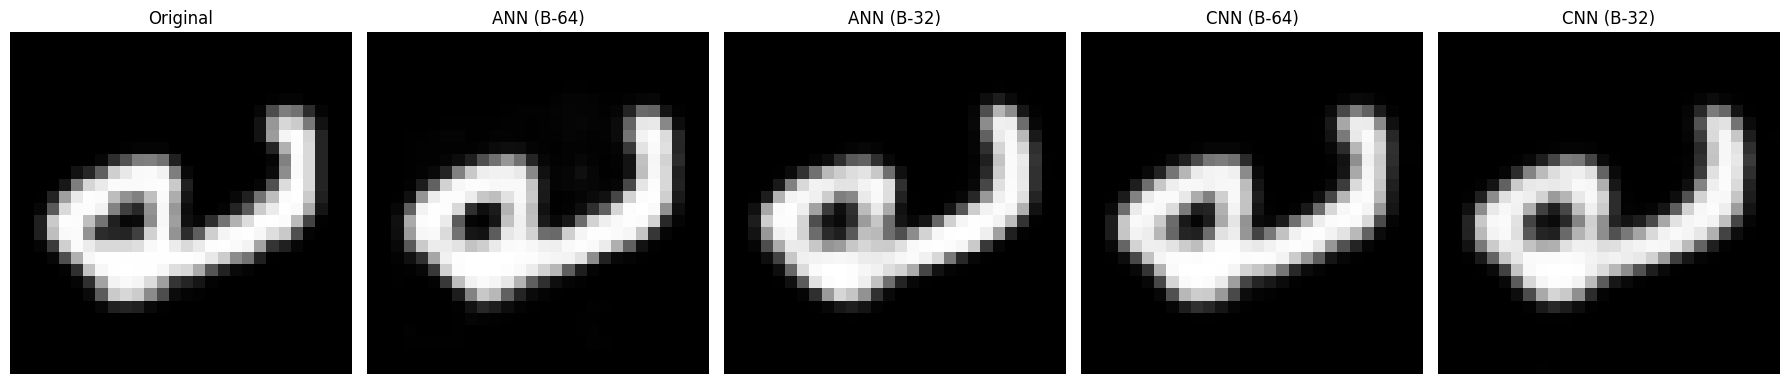

In [62]:
import matplotlib.pyplot as plt
import torch
def visualize_all_designs(models_list, model_names, dataloader):
    images, _ = next(iter(dataloader))
    img = images[0:1].to(device)

    plt.figure(figsize=(18, 5))
    plt.subplot(1, len(models_list) + 1, 1)
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    for i, model in enumerate(models_list):
        model.eval()
        model.to(device)
        with torch.no_grad():
            reconstructed, _ = model(img)

        plt.subplot(1, len(models_list) + 1, i + 2)
        plt.imshow(reconstructed.cpu().detach().squeeze(), cmap='gray')
        plt.title(model_names[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()
my_models = [ann_model_1, ann_model_2, cnn_model_1, cnn_model_2]
my_names = ["ANN (B-64)", "ANN (B-32)", "CNN (B-64)", "CNN (B-32)"]
visualize_all_designs(my_models, my_names, test_loader)

Finished evaluating ANN Design 1 (B-64)...
Finished evaluating ANN Design 2 (B-32)...
Finished evaluating CNN Design 1 (B-64)...
Finished evaluating CNN Design 2 (B-32)...


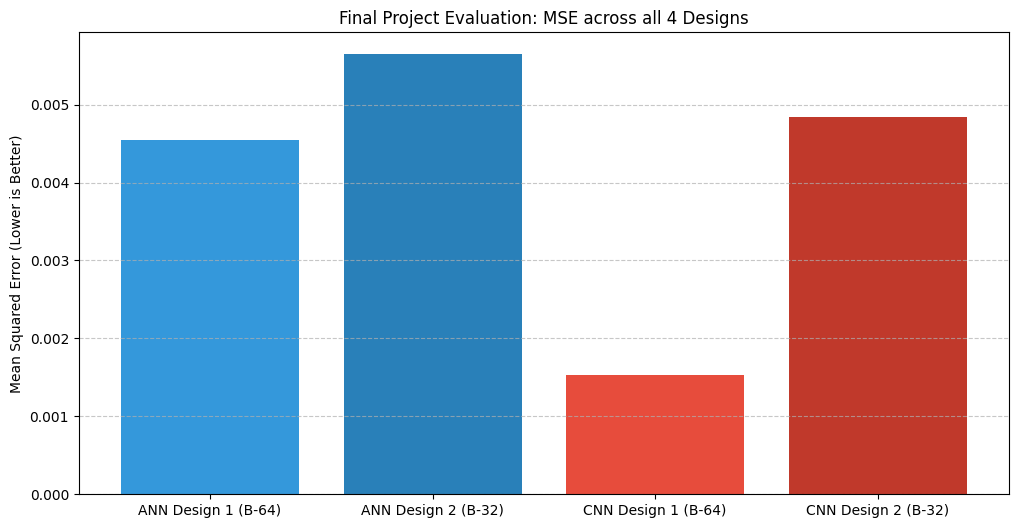

       Backbone Design  Avg Test MSE
2  CNN Design 1 (B-64)      0.001536
0  ANN Design 1 (B-64)      0.004542
3  CNN Design 2 (B-32)      0.004837
1  ANN Design 2 (B-32)      0.005646


In [60]:
import torch.nn.functional as F
import pandas as pd
def evaluate_models(models, dataloader, device):
    results = {}

    for name, model in models.items():
        model.eval()
        model.to(device)
        total_loss = 0

        with torch.no_grad():
            for images, _ in dataloader:
                images = images.to(device)
                reconstructed, _ = model(images)
                loss = F.mse_loss(reconstructed, images)
                total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        results[name] = avg_loss
        print(f"Finished evaluating {name}...")

    return results
my_models = {
    "ANN Design 1 (B-64)": ann_model_1,
    "ANN Design 2 (B-32)": ann_model_2,
    "CNN Design 1 (B-64)": cnn_model_1,
    "CNN Design 2 (B-32)": cnn_model_2
}

loss_data = evaluate_models(my_models, test_loader, device)
plt.figure(figsize=(12, 6))
colors = ['#3498db', '#2980b9', '#e74c3c', '#c0392b']
plt.bar(loss_data.keys(), loss_data.values(), color=colors)

plt.ylabel('Mean Squared Error (Lower is Better)')
plt.title('Final Project Evaluation: MSE across all 4 Designs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
df = pd.DataFrame(list(loss_data.items()), columns=['Backbone Design', 'Avg Test MSE'])
df = df.sort_values(by='Avg Test MSE')
print(df)

Extracting latent representations for CNN Design 2: Latent Space Clusters...


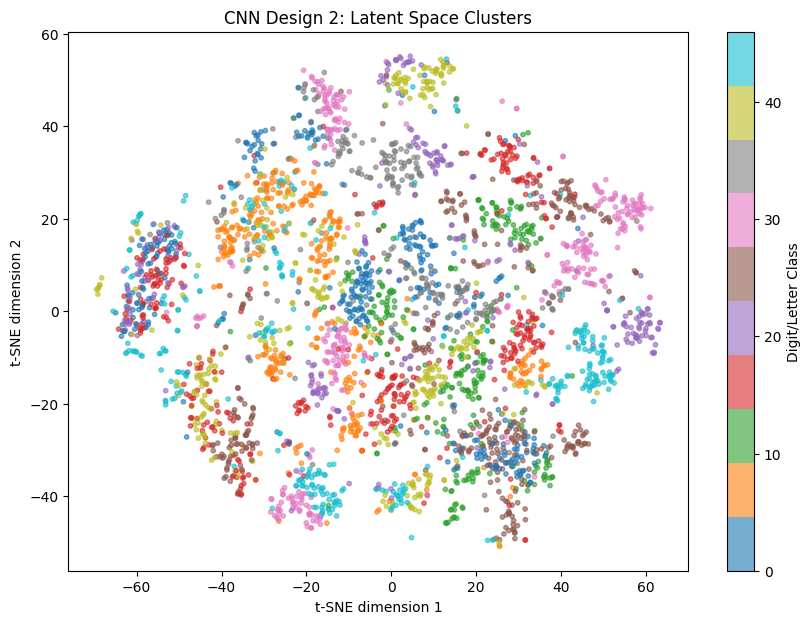

In [63]:
from sklearn.manifold import TSNE

def plot_latent_space(model, dataloader, device, title="Latent Space Visualization"):
    model.eval()
    latents = []
    labels = []

    print(f"Extracting latent representations for {title}...")
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(dataloader):
            _, latent = model(imgs.to(device))
            latents.append(latent.cpu())
            labels.append(lbls)
            if i > 50: break
    latents = torch.cat(latents).numpy()
    labels = torch.cat(labels).numpy()
    tsne = TSNE(n_components=2, random_state=42)
    latents_2d = tsne.fit_transform(latents)
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, label='Digit/Letter Class')
    plt.title(title)
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.show
plot_latent_space(cnn_model_2, test_loader, device, title="CNN Design 2: Latent Space Clusters")